* * *
<pre> Formation Machine Learning            <i> Jour 2 - Apprentissage non supervisé et extensions</i></pre>
* * *

<h1 align="center"> TP2 : clustering, réduction de dimension et au-delà </h1>

<pre align="left"> Auteur : Igor Colin </pre>
* * *

##### Objectifs de la séance
- **Socle (pour tous)** : partitionner sans étiquettes avec **K-means** (et l'appliquer à la **compression d'image**), puis réduire la dimension avec la **PCA**.
- **Modules au choix** (on en prend selon vos envies) : détection d'**anomalies**, **recommandation par factorisation**, **machines de factorisation**, **réseaux de neurones** (MLP et CNN), **clustering spectral**.

Notebook à trous : complétez les blocs `# À COMPLÉTER`. Les modules de la partie 2 sont indépendants : piochez.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)
print("Environnement prêt.")

Environnement prêt.


# Partie 1 - Socle

## K-means

K-means cherche $K$ centres et affecte chaque point au centre le plus proche, en alternant deux étapes (affectation, puis recalcul des centres) pour minimiser l'**inertie** $\sum_i \lVert x_i - \mu_{c(i)}\rVert^2$. On part de groupes synthétiques.

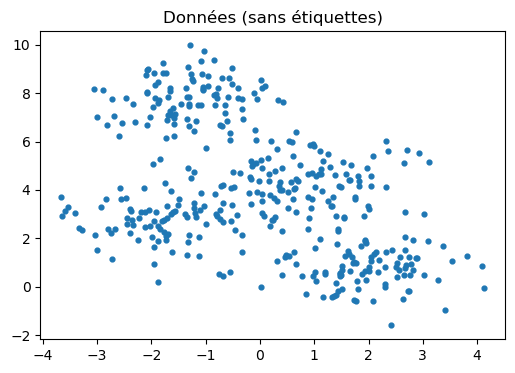

In [3]:
from sklearn.datasets import make_blobs

Xb, _ = make_blobs(n_samples=400, centers=4, cluster_std=0.9, random_state=0)
plt.scatter(Xb[:, 0], Xb[:, 1], s=12); plt.title("Données (sans étiquettes)"); plt.show()

### Exercice 1
Ajustez un `KMeans` à 4 clusters, récupérez les labels (`.labels_`) et les centres (`.cluster_centers_`), puis affichez le résultat.

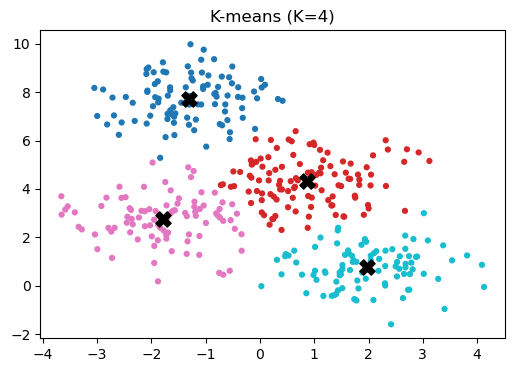

In [4]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=4, n_init=10, random_state=0)
km.fit(Xb)
labels = km.labels_
centres = km.cluster_centers_

plt.scatter(Xb[:, 0], Xb[:, 1], c=labels, cmap="tab10", s=12)
plt.scatter(centres[:, 0], centres[:, 1], c="k", marker="X", s=120)
plt.title("K-means (K=4)"); plt.show()

### Voir K-means converger, étape par étape

Pour *visualiser* l'algorithme, on l'exécute à la main quelques itérations. À chaque étape : (1) on **affecte** chaque point au centre le plus proche, (2) on **recalcule** chaque centre comme la moyenne de ses points. Les centres se déplacent jusqu'à se stabiliser. L'animation ci-dessous (boutons de lecture) montre les premières itérations à partir de centres initiaux aléatoires.

In [5]:
from matplotlib import animation
from IPython.display import HTML
plt.rcParams["animation.embed_limit"] = 30

def kmeans_iterations(X, k=4, n_iter=8, seed=3):
    rng = np.random.RandomState(seed)
    centres = X[rng.choice(len(X), k, replace=False)].astype(float)
    histo = []
    for _ in range(n_iter):
        dist = ((X[:, None, :] - centres[None, :, :]) ** 2).sum(2)
        lab = dist.argmin(1)                      # (1) affectation
        histo.append((centres.copy(), lab.copy()))
        centres = np.array([X[lab == j].mean(0) if (lab == j).any() else centres[j]
                            for j in range(k)])   # (2) recalcul des centres
    return histo

histo = kmeans_iterations(Xb, k=4)

fig_a, ax_a = plt.subplots(figsize=(5, 4)); plt.close(fig_a)
def frame(i):
    ax_a.clear()
    centres, lab = histo[i]
    ax_a.scatter(Xb[:, 0], Xb[:, 1], c=lab, cmap="tab10", s=12)
    ax_a.scatter(centres[:, 0], centres[:, 1], c="k", marker="X", s=180)
    ax_a.set_title(f"Itération {i + 1}/{len(histo)}")

ani = animation.FuncAnimation(fig_a, frame, frames=len(histo), interval=900)
HTML(ani.to_jshtml())

En vrai on ignore le bon $K$. Deux outils :

- la **méthode du coude** : on trace l'inertie en fonction de $K$. Elle décroît toujours, mais le « coude » (là où le gain ralentit nettement) indique un bon compromis.
- le **score de silhouette** : pour chaque point on calcule $a$ = distance moyenne aux points de **son** cluster, et $b$ = distance moyenne aux points du **cluster voisin le plus proche**. La silhouette du point vaut
  $$s = \frac{b - a}{\max(a, b)} \in [-1, 1].$$
  Proche de $1$, le point est bien à l'intérieur de son cluster ; proche de $0$, il est à la frontière ; négatif, il est probablement mal classé. On moyenne sur tous les points : plus le score est haut, mieux les clusters sont compacts et séparés.

### Exercice 2
Complétez la boucle qui calcule l'inertie (`.inertia_`) et la silhouette pour $K = 2..8$. Le $K$ retenu est souvent celui qui **maximise la silhouette**.

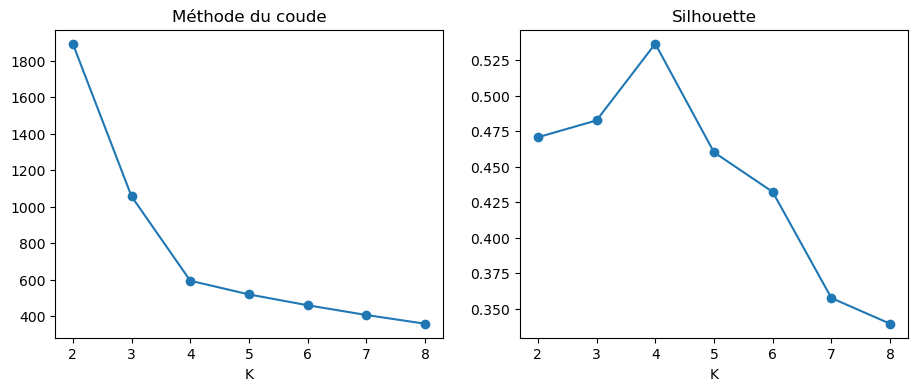

In [6]:
from sklearn.metrics import silhouette_score

Ks = range(2, 9)
inerties, silhouettes = [], []
for k in Ks:
    m = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xb)
    inerties.append(m.inertia_)
    silhouettes.append(silhouette_score(Xb, m.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(list(Ks), inerties, "o-"); a1.set_xlabel("K"); a1.set_title("Méthode du coude")
a2.plot(list(Ks), silhouettes, "o-"); a2.set_xlabel("K"); a2.set_title("Silhouette")
plt.show()

**Attention** : K-means suppose des clusters sphériques de taille comparable. Sur des formes allongées ou imbriquées il échoue (on le verra avec le clustering spectral, plus loin).

## K-means pour la compression d'image

Une image couleur, c'est un nuage de pixels dans l'espace RVB (3 dimensions). En remplaçant chaque pixel par le centre de son cluster, on réduit la palette à $K$ couleurs : c'est de la **quantification couleur**.

image : (427, 640, 3)


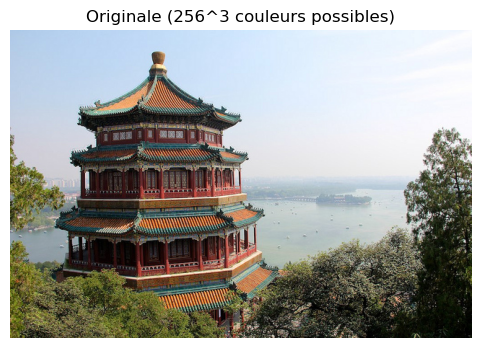

In [7]:
from sklearn.datasets import load_sample_image

img = load_sample_image("china.jpg")
print("image :", img.shape)            # (hauteur, largeur, 3)
pixels = (img / 255.0).reshape(-1, 3)  # nuage de pixels dans [0,1]^3
plt.imshow(img); plt.axis("off"); plt.title("Originale (256^3 couleurs possibles)"); plt.show()

### Exercice 3
Quantifiez l'image sur `K=16` couleurs. Ajustez K-means sur un échantillon de pixels (pour la vitesse), prédisez le cluster de **tous** les pixels, puis reconstruisez l'image en remplaçant chaque pixel par le centre de son cluster.

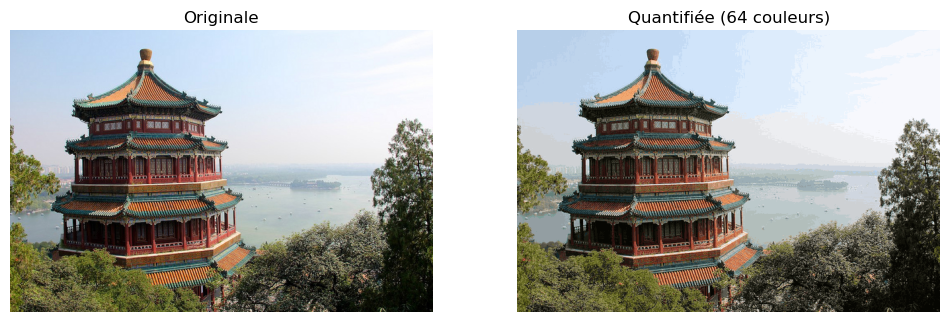

In [8]:
K = 64
echant = pixels[np.random.choice(len(pixels), 10000, replace=False)]

km_img = KMeans(n_clusters=K, n_init=4, random_state=0).fit(echant)
etiq = km_img.predict(pixels)
pixels_quant = km_img.cluster_centers_[etiq]
img_quant = pixels_quant.reshape(img.shape)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
a1.imshow(img); a1.set_title("Originale"); a1.axis("off")
a2.imshow(img_quant); a2.set_title(f"Quantifiée ({K} couleurs)"); a2.axis("off")
plt.show()

## La PCA

L'**analyse en composantes principales** projette les données sur les directions de plus grande variance. Utile pour visualiser, compresser ou débruiter. On l'illustre sur `load_digits` (chiffres 8x8 = 64 dimensions).

In [8]:
from sklearn.datasets import load_digits

dig = load_digits()
Xdig = dig.data
print("digits :", Xdig.shape)

digits : (1797, 64)


### Exercice 4
Ajustez une `PCA` complète, tracez la **variance expliquée cumulée**, et trouvez le nombre de composantes nécessaires pour conserver 90 % de la variance.

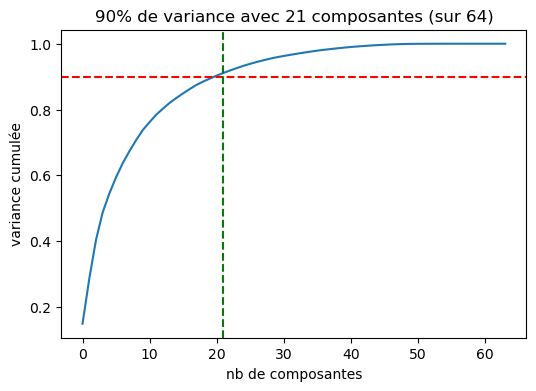

In [9]:
from sklearn.decomposition import PCA

pca = PCA().fit(Xdig)
cumul = np.cumsum(pca.explained_variance_ratio_)
n90 = int(np.argmax(cumul >= 0.90)) + 1

plt.plot(cumul); plt.axhline(0.9, color="r", ls="--")
plt.axvline(n90, color="g", ls="--")
plt.xlabel("nb de composantes"); plt.ylabel("variance cumulée")
plt.title(f"90% de variance avec {n90} composantes (sur 64)"); plt.show()

La PCA permet aussi de **compresser** : on projette sur $k$ composantes puis on reconstruit. On compare l'original à la reconstruction pour quelques valeurs de $k$.

### Exercice 5
Pour chaque `k` de la liste, ajustez `PCA(n_components=k)`, transformez puis reconstruisez (`inverse_transform`) la première image.

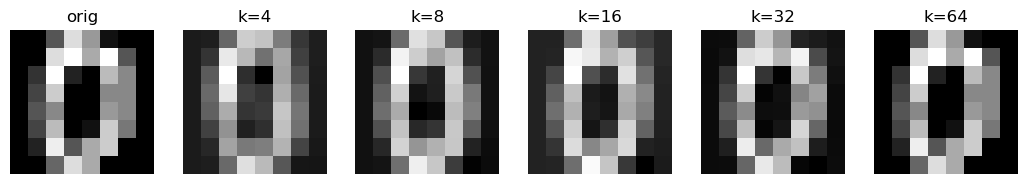

In [10]:
ks = [4, 8, 16, 32, 64]
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(13, 2.5))
axes[0].imshow(Xdig[0].reshape(8, 8), cmap="gray"); axes[0].set_title("orig"); axes[0].axis("off")
for ax, k in zip(axes[1:], ks):
    p = PCA(n_components=k).fit(Xdig)
    recon = p.inverse_transform(p.transform(Xdig[:1]))
    ax.imshow(recon.reshape(8, 8), cmap="gray"); ax.set_title(f"k={k}"); ax.axis("off")
plt.show()

Enfin, projeter en 2D révèle la structure des classes (alors qu'on ne les a jamais données à la PCA).

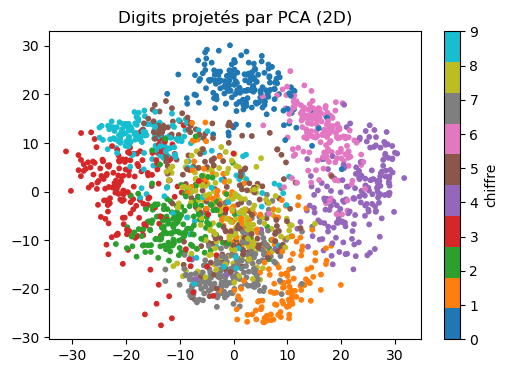

In [11]:
proj = PCA(n_components=2).fit_transform(Xdig)
plt.scatter(proj[:, 0], proj[:, 1], c=dig.target, cmap="tab10", s=10)
plt.colorbar(label="chiffre"); plt.title("Digits projetés par PCA (2D)"); plt.show()

*Bonus* : `TSNE` (non linéaire) sépare souvent mieux les classes que la PCA, au prix d'un calcul plus lourd. Décommentez pour essayer.

In [12]:
# from sklearn.manifold import TSNE
# emb = TSNE(n_components=2, init="pca", random_state=0).fit_transform(Xdig)
# plt.scatter(emb[:, 0], emb[:, 1], c=dig.target, cmap="tab10", s=10)
# plt.title("Digits par t-SNE"); plt.colorbar(); plt.show()

# Partie 2 - Modules au choix

Les sections suivantes sont **indépendantes**. Choisissez selon vos centres d'intérêt.

## Détection d'anomalies

But : repérer les points qui n'appartiennent pas à la distribution normale, **sans étiquette**. Cas d'usage : fraude, panne, intrusion. On fabrique un nuage dense pollué de points aberrants.

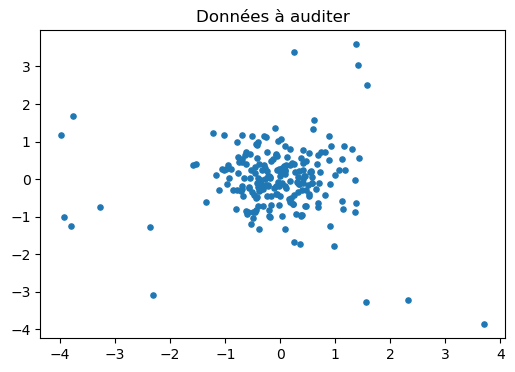

In [13]:
rng = np.random.RandomState(0)
normal = 0.6 * rng.randn(200, 2)
aberrants = rng.uniform(-4, 4, size=(20, 2))
Xa = np.vstack([normal, aberrants])
plt.scatter(Xa[:, 0], Xa[:, 1], s=14); plt.title("Données à auditer"); plt.show()

### Exercice 6
`IsolationForest` isole les points anormaux par partitionnement aléatoire. Ajustez-le (`contamination=0.1`) ; `fit_predict` renvoie `+1` pour un point normal et `-1` pour une anomalie.

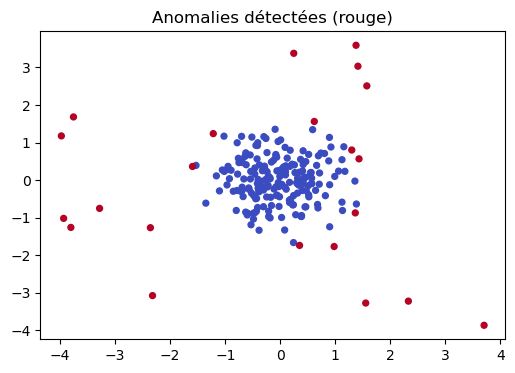

anomalies détectées : 22


In [14]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1, random_state=0)
pred = iso.fit_predict(Xa)

plt.scatter(Xa[:, 0], Xa[:, 1], c=(pred == -1), cmap="coolwarm", s=18)
plt.title("Anomalies détectées (rouge)"); plt.show()
print("anomalies détectées :", int((pred == -1).sum()))

### Exercice 7 : Isolation Forest vs One-Class SVM

Les deux méthodes détectent des anomalies mais avec des hypothèses différentes :
- **Isolation Forest** isole les points par découpages aléatoires de l'espace : un point qu'on isole en peu de coupes est probablement anormal.
- **One-Class SVM** apprend une **frontière lisse** qui entoure la zone dense des données « normales » ; ce qui tombe dehors est une anomalie.

Ajustez un `OneClassSVM` (`nu=0.1`, `gamma="scale"`) et comparez ses détections à celles d'Isolation Forest, côte à côte. (`LocalOutlierFactor`, basé sur la densité locale, est une troisième option.)

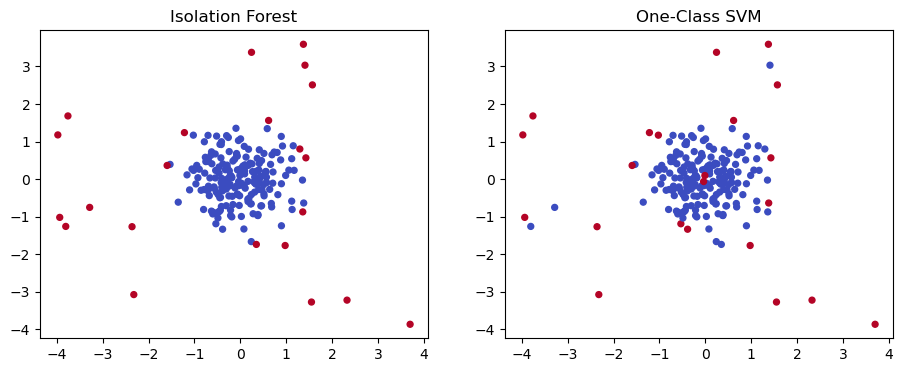

IF : 22 anomalies | SVM : 22 anomalies | accord : 95%


In [15]:
from sklearn.svm import OneClassSVM

pred_iso = iso.fit_predict(Xa)                 # Isolation Forest (déjà vu)
ocsvm = OneClassSVM(nu=0.1, gamma="scale")
pred_svm = ocsvm.fit_predict(Xa)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.scatter(Xa[:, 0], Xa[:, 1], c=(pred_iso == -1), cmap="coolwarm", s=18)
a1.set_title("Isolation Forest")
a2.scatter(Xa[:, 0], Xa[:, 1], c=(pred_svm == -1), cmap="coolwarm", s=18)
a2.set_title("One-Class SVM")
plt.show()

accord = np.mean((pred_iso == -1) == (pred_svm == -1))
print(f"IF : {int((pred_iso==-1).sum())} anomalies | "
      f"SVM : {int((pred_svm==-1).sum())} anomalies | accord : {accord:.0%}")

## Recommandation par factorisation

Une matrice utilisateurs x articles de notes, très incomplète. La **factorisation** $R \approx U V^\top$ résume chaque utilisateur et chaque article par un petit vecteur de **facteurs latents** ; le produit reconstruit les notes manquantes. C'est le cœur du filtrage collaboratif (et, en version supervisée avec des variables, des *factorization machines* type prédiction de clic Avazu).

In [16]:
# 6 utilisateurs x 5 films, notes de 1 à 5 (0 = non vu)
R = np.array([
    [5, 4, 0, 1, 0],
    [4, 5, 3, 0, 1],
    [0, 0, 5, 4, 4],
    [1, 0, 4, 5, 0],
    [0, 1, 4, 0, 5],
    [5, 4, 0, 1, 1],
], dtype=float)
print("matrice de notes (0 = manquant) :\n", R)

matrice de notes (0 = manquant) :
 [[5. 4. 0. 1. 0.]
 [4. 5. 3. 0. 1.]
 [0. 0. 5. 4. 4.]
 [1. 0. 4. 5. 0.]
 [0. 1. 4. 0. 5.]
 [5. 4. 0. 1. 1.]]


### Exercice 8
Avec `NMF` (factorisation à valeurs positives), apprenez `n_components=2` facteurs latents et reconstruisez la matrice complète `R_hat = U @ V`. Comparez les notes prédites aux trous (0).

In [17]:
from sklearn.decomposition import NMF

modele = NMF(n_components=2, init="nndsvda", random_state=0, max_iter=500)
U = modele.fit_transform(R)
V = modele.components_
R_hat = U @ V

np.set_printoptions(precision=1, suppress=True)
print("notes reconstruites :\n", R_hat)
print("\nPour l'utilisateur 2 (films 0 et 1 non vus), prédictions :",
      np.round(R_hat[2, :2], 1))

notes reconstruites :
 [[4.7 4.3 0.3 0.3 0.2]
 [4.6 4.3 2.  1.3 1.3]
 [0.  0.1 5.4 3.6 3.8]
 [0.5 0.6 3.8 2.5 2.6]
 [0.4 0.5 3.9 2.6 2.7]
 [4.7 4.3 0.7 0.5 0.4]]

Pour l'utilisateur 2 (films 0 et 1 non vus), prédictions : [0.  0.1]


## Machines de factorisation (Factorization Machines)

Un modèle linéaire prédit $\hat y = w_0 + \sum_i w_i x_i$ : chaque variable agit **séparément**. Or souvent ce qui compte, ce sont les **interactions** entre variables (un utilisateur aime tel film *parce que* c'est ce genre-là pour *lui*). On pourrait ajouter un poids $w_{ij}$ par paire de variables, mais cela fait $O(n^2)$ paramètres et la plupart des paires ne sont **jamais observées** ensemble.

Les **machines de factorisation** contournent ça : à chaque variable $i$ on associe un **vecteur latent** $v_i \in \mathbb{R}^k$, et la force de l'interaction entre $i$ et $j$ est le produit scalaire $\langle v_i, v_j\rangle$. Le modèle s'écrit

$$\hat y = w_0 + \sum_i w_i x_i + \sum_{i<j} \langle v_i, v_j\rangle\, x_i x_j.$$

Avantages : seulement $O(nk)$ paramètres, et deux variables peuvent interagir **même si on ne les a jamais vues ensemble** (via leurs vecteurs latents). C'est le modèle de référence pour la prédiction de clic (CTR, type Avazu) et la recommandation.

Pour bien le montrer, on fabrique un jeu où la cible dépend **essentiellement d'interactions** entre trois variables catégorielles (encodées en one-hot) : un modèle linéaire restera faible, la FM devrait nettement mieux faire.

In [18]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score

rng = np.random.RandomState(0)
n_modalites = [8, 8, 6]                       # 3 variables catégorielles
offsets = np.cumsum([0] + n_modalites)[:-1]
d = sum(n_modalites)                          # dimension du one-hot
V_true = rng.randn(d, 3)
V_true -= V_true.mean(0)                      # pas d'effet linéaire : tout est interaction

def genere(n):
    cats = np.stack([rng.randint(0, c, n) for c in n_modalites], axis=1)
    idx = cats + offsets                      # indices one-hot actifs (3 par ligne)
    X = np.zeros((n, d), dtype=np.float32)
    logit = np.zeros(n, dtype=np.float32)
    for r in range(n):
        X[r, idx[r]] = 1.0
        vs = V_true[idx[r]]
        logit[r] = sum(vs[a] @ vs[b] for a in range(3) for b in range(a + 1, 3))
    y = (rng.rand(n) < 1 / (1 + np.exp(-logit))).astype(np.float32)
    return X, y

Xfm, yfm = genere(4000)
Xfm_tr, Xfm_te, yfm_tr, yfm_te = Xfm[:3000], Xfm[3000:], yfm[:3000], yfm[3000:]
print("X one-hot :", Xfm.shape, "| taux de positifs :", round(float(yfm.mean()), 2))

X one-hot : (4000, 22) | taux de positifs : 0.4


In [19]:
# Référence : modèle linéaire (pas d'interactions)
from sklearn.linear_model import LogisticRegression

lin = LogisticRegression(max_iter=1000).fit(Xfm_tr, yfm_tr)
auc_lin = roc_auc_score(yfm_te, lin.predict_proba(Xfm_te)[:, 1])
print(f"Modèle linéaire : AUC test = {auc_lin:.3f}  (faible : ne capte pas les interactions)")

Modèle linéaire : AUC test = 0.662  (faible : ne capte pas les interactions)


### Exercice 9
La FM est définie ci-dessous (le terme d'interaction utilise la forme efficace $\tfrac12\sum_f[(xV)_f^2 - (x^2 V^2)_f]$). Complétez la boucle d'entraînement (backward + step), comme pour un réseau de neurones.

In [20]:
class FM(nn.Module):
    def __init__(self, d, k=8):
        super().__init__()
        self.lin = nn.Linear(d, 1)
        self.V = nn.Parameter(0.01 * torch.randn(d, k))   # un vecteur latent par variable
    def forward(self, x):
        lin = self.lin(x).squeeze(1)
        xv = x @ self.V
        xv2 = (x * x) @ (self.V * self.V)
        interaction = 0.5 * (xv ** 2 - xv2).sum(1)
        return lin + interaction

torch.manual_seed(0)
fm = FM(d, k=8)
opt = torch.optim.Adam(fm.parameters(), lr=0.05)
bce = nn.BCEWithLogitsLoss()
Xt, yt = torch.tensor(Xfm_tr), torch.tensor(yfm_tr)

for epoch in range(120):
    opt.zero_grad()
    loss = bce(fm(Xt), yt)
    loss.backward()
    opt.step()

with torch.no_grad():
    proba = torch.sigmoid(fm(torch.tensor(Xfm_te))).numpy()
auc_fm = roc_auc_score(yfm_te, proba)
print(f"Factorization Machine : AUC test = {auc_fm:.3f}  (vs linéaire {auc_lin:.3f})")

Factorization Machine : AUC test = 0.875  (vs linéaire 0.662)


Le modèle linéaire reste faible (il ne voit pas les interactions entre variables), alors que la FM récupère bien plus de signal grâce aux interactions encodées dans les **vecteurs latents** : c'est exactement ce qui la rend précieuse en CTR et en recommandation.

## Réseaux de neurones (MLP et CNN)

On revient en supervisé, mais avec des modèles plus expressifs. On classe les chiffres `digits` (8x8) d'abord avec un **perceptron multicouche (MLP)**, puis un **réseau convolutif (CNN)**. Entraînement volontairement court pour rester rapide sur CPU.

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)
Xtr, Xte, ytr, yte = train_test_split(dig.data, dig.target, test_size=0.3, random_state=0)
sc = StandardScaler().fit(Xtr)
Xtr_t = torch.tensor(sc.transform(Xtr), dtype=torch.float32)
Xte_t = torch.tensor(sc.transform(Xte), dtype=torch.float32)
ytr_t = torch.tensor(ytr); yte_t = torch.tensor(yte)
loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=64, shuffle=True)

def evalue(model, X, y, conv=False):
    model.eval()
    with torch.no_grad():
        xx = X.view(-1, 1, 8, 8) if conv else X
        pred = model(xx).argmax(1)
    return (pred == y).float().mean().item()

def n_params(model):   # nombre de paramètres entraînables
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Exercice 10
Un **MLP** (perceptron multicouche) enchaîne des couches entièrement connectées séparées par des non-linéarités. Ici : `Linear(64, 32)` projette les 64 pixels sur 32 neurones, `ReLU` ajoute la non-linéarité (sans elle, deux couches linéaires = une seule), `Linear(32, 10)` produit un score par chiffre.

Deux choses à compléter :
1. dans le `nn.Sequential`, insérez l'activation **`nn.ReLU()`** entre les deux couches linéaires ;
2. dans la boucle, l'**étape d'optimisation** : `loss.backward()` calcule les gradients, puis `opt.step()` met à jour les poids (le `opt.zero_grad()` qui les remet à zéro est déjà là).

On affiche aussi le **nombre de paramètres entraînables** pour comparer avec le CNN ensuite.

In [22]:
mlp = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10),
)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-2)
perte = nn.CrossEntropyLoss()

for epoch in range(15):
    for xb, yb in loader:
        opt.zero_grad()
        sortie = mlp(xb)
        l = perte(sortie, yb)
        l.backward()
        opt.step()
mlp_acc = evalue(mlp, Xte_t, yte_t)
print(f"MLP - accuracy test : {mlp_acc:.3f} | paramètres entraînables : {n_params(mlp)}")

MLP - accuracy test : 0.974 | paramètres entraînables : 2410


### Exercice 11
Un **CNN** exploite la structure 2D de l'image : un même petit filtre balaie toute l'image (**partage de poids**) et détecte des motifs locaux, ce qui demande **beaucoup moins de paramètres** qu'un MLP pour une qualité comparable. La couche convolutive est déjà écrite ; complétez juste l'entraînement (backward + step, identique au MLP).

In [23]:
class PetitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))  # 8x8 -> 4x4
        self.tete = nn.Sequential(nn.Flatten(), nn.Linear(8 * 4 * 4, 10))
    def forward(self, x):
        return self.tete(self.conv(x))

cnn = PetitCNN()
opt = torch.optim.Adam(cnn.parameters(), lr=1e-2)

for epoch in range(15):
    for xb, yb in loader:
        xb = xb.view(-1, 1, 8, 8)
        opt.zero_grad()
        l = perte(cnn(xb), yb)
        l.backward()
        opt.step()
cnn_acc = evalue(cnn, Xte_t, yte_t, conv=True)
print(f"CNN - accuracy test : {cnn_acc:.3f} | paramètres entraînables : {n_params(cnn)}")

CNN - accuracy test : 0.976 | paramètres entraînables : 1370


### Comparaison MLP / CNN

On met les deux modèles côte à côte : accuracy en test et nombre de paramètres entraînables.

In [24]:
print(f"MLP : {n_params(mlp):5d} paramètres | accuracy = {mlp_acc:.3f}")
print(f"CNN : {n_params(cnn):5d} paramètres | accuracy = {cnn_acc:.3f}")
print()
print("Le CNN atteint une accuracy comparable (souvent meilleure) avec nettement")
print("moins de paramètres : le partage de poids du filtre convolutif est plus")
print("efficace que les connexions denses du MLP pour des données en image.")

MLP :  2410 paramètres | accuracy = 0.974
CNN :  1370 paramètres | accuracy = 0.976

Le CNN atteint une accuracy comparable (souvent meilleure) avec nettement
moins de paramètres : le partage de poids du filtre convolutif est plus
efficace que les connexions denses du MLP pour des données en image.


## Clustering spectral

K-means trace des frontières droites et échoue sur des formes non convexes (spirales, croissants). Le **clustering spectral** raisonne autrement : au lieu de la distance aux centres, il regarde **qui est proche de qui**.

L'idée se fait en trois temps :
1. on construit une **matrice de similarité** entre points, souvent via un **noyau** (kernel). Le noyau gaussien $s(x_i, x_j) = \exp(-\lVert x_i - x_j\rVert^2 / 2\sigma^2)$ vaut ~1 pour deux points proches et ~0 pour deux points éloignés (variante : ne relier que les $k$ plus proches voisins). Cette matrice définit un **graphe** où les points voisins sont connectés.
2. on cherche à **couper** ce graphe en groupes en sectionnant le moins d'arêtes possible, ce qui passe par les **vecteurs propres** d'une matrice dérivée du graphe (le *laplacien*).
3. on applique enfin un simple K-means dans ce nouvel espace.

Pas besoin du détail mathématique ici : retenez qu'on remplace « distance au centre » par « connectivité dans un graphe de similarité », ce qui permet de suivre des formes courbes. Démonstration sur deux croissants imbriqués.

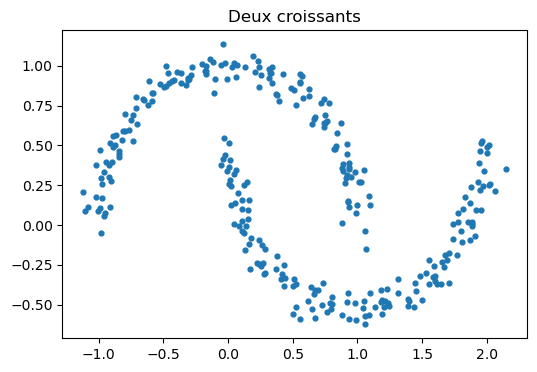

In [25]:
from sklearn.datasets import make_moons

Xm, _ = make_moons(n_samples=300, noise=0.06, random_state=0)
plt.scatter(Xm[:, 0], Xm[:, 1], s=12); plt.title("Deux croissants"); plt.show()

### Exercice 12
Comparez `KMeans(2)` et `SpectralClustering(2, affinity="nearest_neighbors")` sur ce jeu.

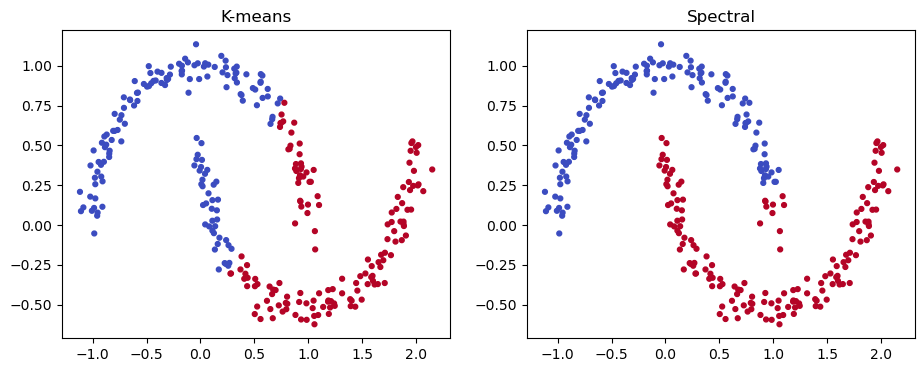

In [26]:
from sklearn.cluster import SpectralClustering

lab_km = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xm)
lab_sp = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                            random_state=0).fit_predict(Xm)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.scatter(Xm[:, 0], Xm[:, 1], c=lab_km, cmap="coolwarm", s=12); a1.set_title("K-means")
a2.scatter(Xm[:, 0], Xm[:, 1], c=lab_sp, cmap="coolwarm", s=12); a2.set_title("Spectral")
plt.show()

## Bilan du jour 2

- **K-means** partitionne en minimisant l'inertie ; on choisit $K$ par le coude / la silhouette. Appliqué aux pixels, il **compresse** une image.
- La **PCA** projette sur les directions de plus forte variance : visualisation, compression, débruitage.
- Au-delà du socle : **détection d'anomalies** (Isolation Forest vs One-Class SVM), **factorisation** pour la recommandation (NMF) et **machines de factorisation** (interactions via vecteurs latents), **réseaux de neurones** (MLP/CNN, à paramètres comparés), **clustering spectral** pour des formes non convexes.
- Le fil conducteur des deux jours : choisir la **représentation** et la **fonction objectif** adaptées au problème, puis laisser l'optimisation faire le reste.